In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"
%matplotlib inline

**1. Data Loading & Inspection**

In [67]:
df = pd.read_csv("AmesHousing.csv")
print("Shape:", df.shape)
df.info()

Shape: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 

In [68]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


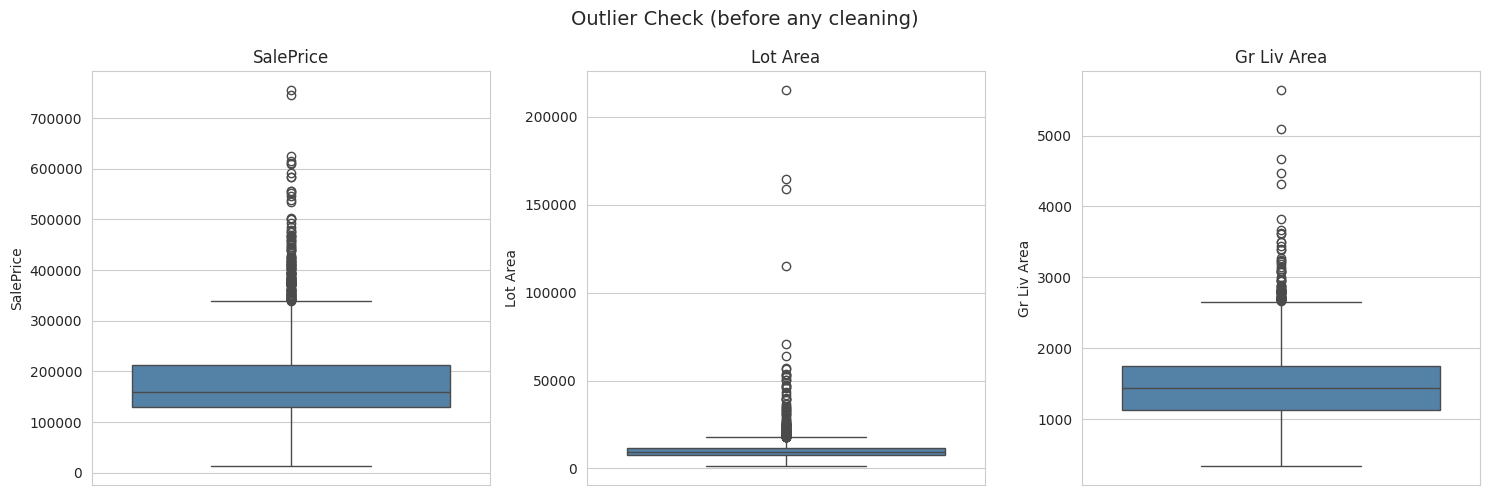

SalePrice       -> 137 outlier(s) خارج حدود IQR (4.7% من البيانات)
Lot Area        -> 127 outlier(s) خارج حدود IQR (4.3% من البيانات)
Gr Liv Area     -> 75 outlier(s) خارج حدود IQR (2.6% من البيانات)


In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["SalePrice", "Lot Area", "Gr Liv Area"]):
    sns.boxplot(y=df[col], ax=ax, color="steelblue")
    ax.set_title(col)
fig.suptitle("Outlier Check (before any cleaning)", fontsize=14)
plt.tight_layout()
plt.savefig("fig_outliers_raw.png", dpi=150)
plt.show()

for col in ["SalePrice", "Lot Area", "Gr Liv Area"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:15s} -> {n_outliers} outlier(s) خارج حدود IQR ({n_outliers/len(df)*100:.1f}% من البيانات)")

**2. Missing Value Treatment**

In [70]:
num_cols = list(set(df.describe().columns.to_list()) - {"PID", "Order"})
missing_counts = df[num_cols].isnull().sum()
print("Numeric columns with missing values:")
print(missing_counts[missing_counts > 0])

Numeric columns with missing values:
BsmtFin SF 2        1
Bsmt Half Bath      2
Garage Cars         1
Mas Vnr Area       23
Garage Yr Blt     159
BsmtFin SF 1        1
Lot Frontage      490
Total Bsmt SF       1
Bsmt Unf SF         1
Bsmt Full Bath      2
Garage Area         1
dtype: int64


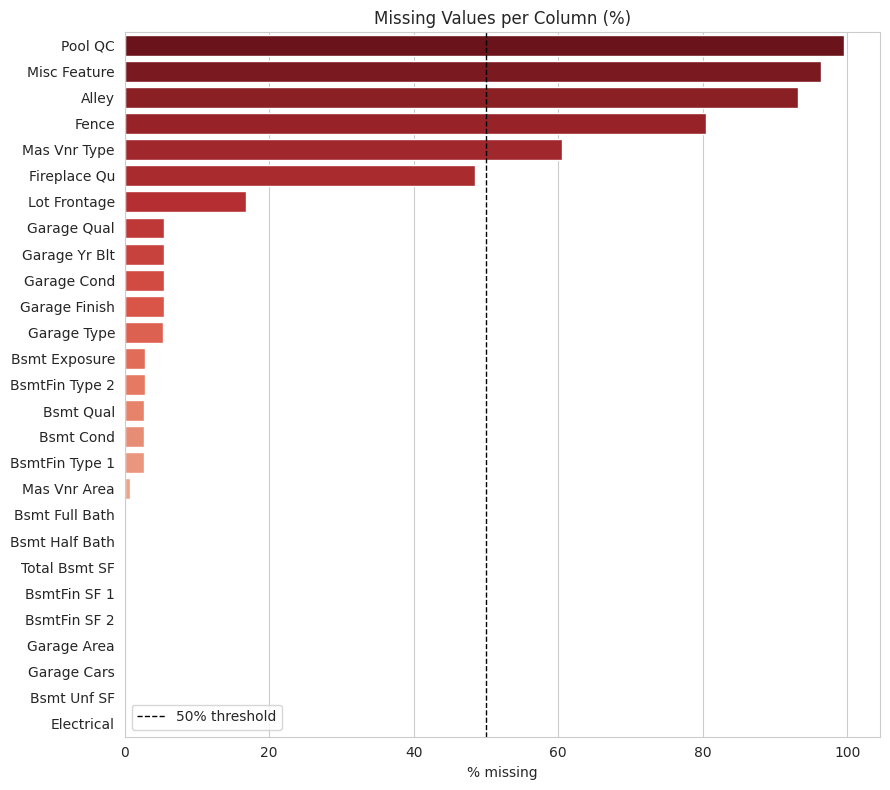

In [71]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(9, 8))
sns.barplot(x=missing_pct.values, y=missing_pct.index, hue=missing_pct.index, palette="Reds_r", legend=False)
plt.title("Missing Values per Column (%)")
plt.xlabel("% missing")
plt.ylabel("")
plt.axvline(50, color="black", linestyle="--", linewidth=1, label="50% threshold")
plt.legend()
plt.tight_layout()
plt.savefig("fig_missing_values.png", dpi=150)
plt.show()

In [72]:
df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(df["Mas Vnr Area"].median())

In [73]:
df.loc[df["Garage Yr Blt"] == 2207, "Garage Yr Blt"] = 2007
has_garage = df["Garage Type"].notna()
median_garage_yr = df.loc[has_garage, "Garage Yr Blt"].median()
df.loc[has_garage & df["Garage Yr Blt"].isnull(), "Garage Yr Blt"] = median_garage_yr
df["Has_Garage"] = has_garage.astype(int)

In [74]:
df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())

In [75]:
cols_to_fill_zero = [
    "Bsmt Half Bath", "Bsmt Full Bath", "BsmtFin SF 1", "BsmtFin SF 2",
    "Total Bsmt SF", "Bsmt Unf SF", "Garage Cars", "Garage Area",
]
df[cols_to_fill_zero] = df[cols_to_fill_zero].fillna(0)

In [76]:
cat_cols = df.select_dtypes(exclude=["number"]).columns
missing_cat = df[cat_cols].isnull().sum()
print("Categorical columns with missing values:")
print(missing_cat[missing_cat > 0])

Categorical columns with missing values:
Alley             2732
Mas Vnr Type      1775
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin Type 2      81
Electrical           1
Fireplace Qu      1422
Garage Type        157
Garage Finish      159
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


In [77]:
mode_col = ["Electrical"]
none_cols = [
    "Alley", "Mas Vnr Type", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure",
    "BsmtFin Type 1", "BsmtFin Type 2", "Fireplace Qu", "Garage Type",
    "Garage Finish", "Garage Qual", "Garage Cond", "Pool QC", "Fence", "Misc Feature",
]
for col in mode_col:
    df[col] = df[col].fillna(df[col].mode()[0])
for col in none_cols:
    df[col] = df[col].fillna("NA")

print("Total remaining missing values:", df.isnull().sum().sum())

Total remaining missing values: 157


3. Feature Engineering

In [78]:
cols_to_binary = ["Pool QC", "Misc Feature", "Alley", "Fence"]
for col in cols_to_binary:
    df[col] = df[col].apply(lambda x: 0 if x == "NA" else 1)
    df.rename(columns={col: f"Has_{col}"}, inplace=True)

df[["Has_Pool QC", "Has_Misc Feature", "Has_Alley", "Has_Fence"]].head()

,Has_Pool QC,Has_Misc Feature,Has_Alley,Has_Fence
0,0,0,0,0
1,0,0,0,1
2,0,1,0,0
3,0,0,0,0
4,0,0,0,1


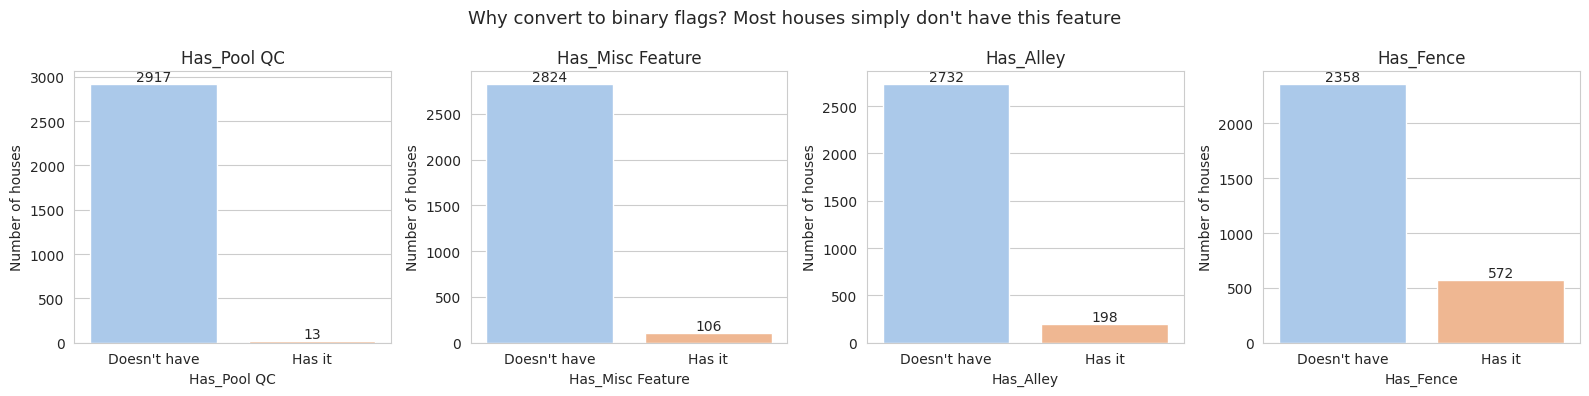

In [79]:
cols_to_binary_check = ["Has_Pool QC", "Has_Misc Feature", "Has_Alley", "Has_Fence"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cols_to_binary_check):
    vc = df[col].map({0: "Doesn't have", 1: "Has it"}).value_counts()
    sns.barplot(x=vc.index, y=vc.values, ax=ax, hue=vc.index, palette="pastel", legend=False)
    ax.set_title(col)
    ax.set_ylabel("Number of houses")
    for i, v in enumerate(vc.values):
        ax.text(i, v, str(v), ha="center", va="bottom")
fig.suptitle("Why convert to binary flags? Most houses simply don't have this feature", fontsize=13)
plt.tight_layout()
plt.savefig("fig_has_flags.png", dpi=150)
plt.show()

4. Low-Variance Feature Review

In [80]:
num_cols = list(set(df.describe().columns.to_list()) - {"PID", "Order"})
cat_cols = list(set(df.columns.to_list()) - set(num_cols) - {"PID", "Order"})


def review_low_variance_columns(
    df, num_cols, cat_cols, threshold=0.8, price_gap_pct=10,
    protected_cols=None, min_group_size=20,
):
    """
    Flags and drops columns that are dominated by a single value AND show
    no meaningful relationship with SalePrice.

    - Numeric columns: dropped if |correlation with SalePrice| < 0.1.
    - Categorical columns: dropped if the price gap between the dominant
      category and the rest is below `price_gap_pct`, OR if the minority
      group is too small (< min_group_size) to trust the comparison.

    Returns the filtered df, the list of dropped columns, and a decision
    log (used later for the summary chart).
    """
    protected_cols = protected_cols or []
    cols_to_drop = []
    decision_log = []

    for col in df.columns:
        if col in ["Order", "PID", "SalePrice"] + protected_cols:
            continue

        top_freq = df[col].value_counts(dropna=False, normalize=True).iloc[0]
        if top_freq <= threshold:
            continue

        if col in num_cols:
            corr = abs(df[col].corr(df["SalePrice"]))
            decision = "DROP" if corr < 0.1 else "KEEP"
            reason = f"corr={corr:.3f}"
        else:
            dominant_value = df[col].value_counts(dropna=False).idxmax()
            dominant_mask = df[col] == dominant_value
            other_mask = ~dominant_mask

            if other_mask.sum() < min_group_size:
                decision = "DROP"
                reason = f"minority group too small (n={other_mask.sum()})"
            else:
                dominant_price = df.loc[dominant_mask, "SalePrice"].mean()
                other_price = df.loc[other_mask, "SalePrice"].mean()
                price_gap = abs(dominant_price - other_price) / df["SalePrice"].mean() * 100
                decision = "DROP" if price_gap < price_gap_pct else "KEEP"
                reason = f"price gap={price_gap:.1f}%"

        decision_log.append({"column": col, "decision": decision, "dominance": top_freq, "reason": reason})
        print(f"{decision}  {col:20s} | dominance={top_freq:.1%} | {reason}")
        if decision == "DROP":
            cols_to_drop.append(col)

    return df.drop(columns=cols_to_drop), cols_to_drop, pd.DataFrame(decision_log)

In [81]:
protected = ["Has_Pool QC", "Has_Misc Feature", "Has_Alley", "Has_Fence", "Has_Garage"]
df, dropped_cols, decision_log = review_low_variance_columns(df, num_cols=num_cols, cat_cols=cat_cols, protected_cols=protected)
print(f"\nTotal low-variance columns dropped: {len(dropped_cols)}")
print("Shape after low-variance filtering:", df.shape)

DROP  Street               | dominance=99.6% | minority group too small (n=12)
KEEP  Land Contour         | dominance=89.9% | price gap=11.2%
DROP  Utilities            | dominance=99.9% | minority group too small (n=3)
KEEP  Land Slope           | dominance=95.2% | price gap=14.1%
KEEP  Condition 1          | dominance=86.1% | price gap=12.9%
DROP  Condition 2          | dominance=99.0% | price gap=9.8%
KEEP  Bldg Type            | dominance=82.8% | price gap=12.9%
KEEP  Roof Matl            | dominance=98.5% | price gap=25.7%
KEEP  Exter Cond           | dominance=87.0% | price gap=15.4%
KEEP  Bsmt Cond            | dominance=89.3% | price gap=15.7%
KEEP  BsmtFin Type 2       | dominance=85.3% | price gap=14.1%
DROP  BsmtFin SF 2         | dominance=88.0% | corr=0.006
KEEP  Heating              | dominance=98.5% | price gap=28.7%
KEEP  Central Air          | dominance=93.3% | price gap=46.8%
KEEP  Electrical           | dominance=91.6% | price gap=38.1%
DROP  Low Qual Fin SF      | d

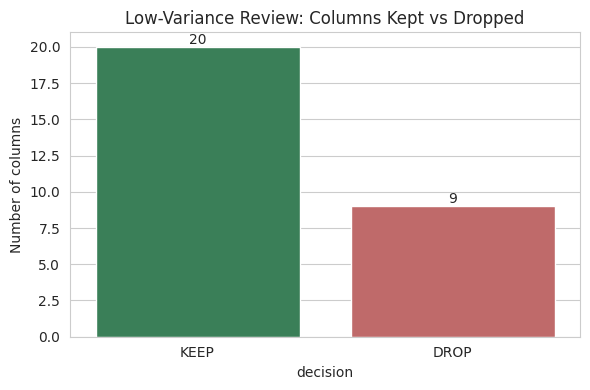

In [82]:
summary = decision_log["decision"].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=summary.index, y=summary.values, hue=summary.index,
            palette={"KEEP": "seagreen", "DROP": "indianred"}, legend=False)
plt.title("Low-Variance Review: Columns Kept vs Dropped")
plt.ylabel("Number of columns")
for i, v in enumerate(summary.values):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.savefig("fig_lowvariance_summary.png", dpi=150)
plt.show()

5. Redundancy Removal

In [83]:
num_cols = list(set(df.describe().columns.to_list()) - {"PID", "Order"})
corr_matrix = df[num_cols].corr()
corr_matrix_no_target = corr_matrix.drop(["SalePrice"], axis=0).drop(["SalePrice"], axis=1)

REDUNDANCY_THRESHOLD = 0.8  # standard cutoff for "strongly correlated"
cols_to_drop_redundant = set()
cols = corr_matrix_no_target.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col_i, col_j = cols[i], cols[j]
        corr_value = corr_matrix_no_target.loc[col_i, col_j]
        if abs(corr_value) > REDUNDANCY_THRESHOLD:
            corr_i_target = abs(corr_matrix.loc[col_i, "SalePrice"])
            corr_j_target = abs(corr_matrix.loc[col_j, "SalePrice"])
            weaker_col = col_j if corr_i_target >= corr_j_target else col_i
            cols_to_drop_redundant.add(weaker_col)
            print(f"{col_i:20s} <-> {col_j:20s} | corr={corr_value:.3f} -> dropping '{weaker_col}'")

df = df.drop(columns=list(cols_to_drop_redundant))
print(f"\nRedundant columns dropped: {sorted(cols_to_drop_redundant)}")
print("Shape after removing redundant features:", df.shape)

Garage Cars          <-> Garage Area          | corr=0.890 -> dropping 'Garage Area'
Year Built           <-> Garage Yr Blt        | corr=0.843 -> dropping 'Garage Yr Blt'
TotRms AbvGrd        <-> Gr Liv Area          | corr=0.808 -> dropping 'TotRms AbvGrd'
1st Flr SF           <-> Total Bsmt SF        | corr=0.800 -> dropping '1st Flr SF'

Redundant columns dropped: ['1st Flr SF', 'Garage Area', 'Garage Yr Blt', 'TotRms AbvGrd']
Shape after removing redundant features: (2930, 70)


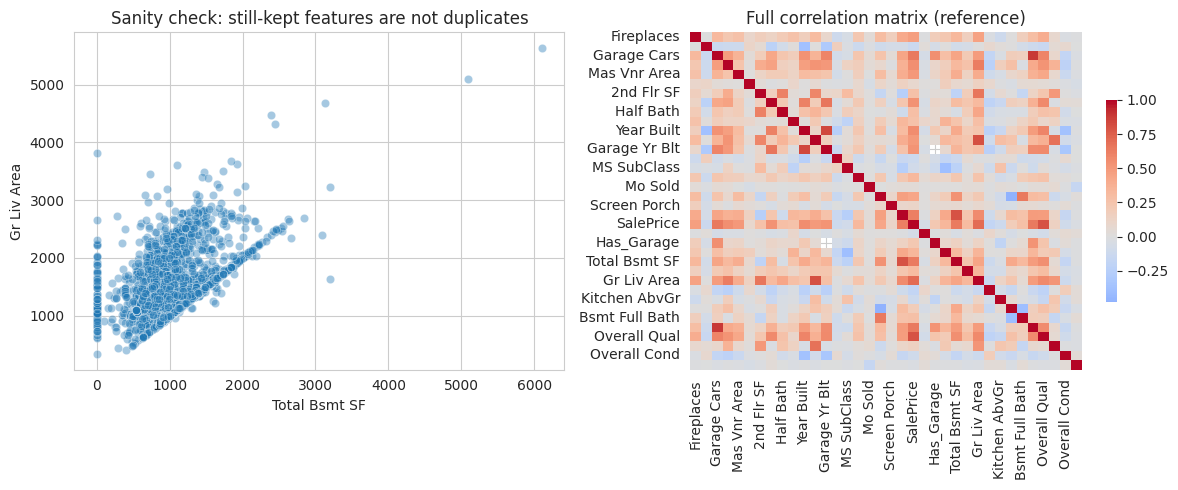

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x="Total Bsmt SF", y="Gr Liv Area", ax=axes[0], alpha=0.4)
axes[0].set_title("Sanity check: still-kept features are not duplicates")
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=axes[1], cbar_kws={"shrink": 0.6})
axes[1].set_title("Full correlation matrix (reference)")
plt.tight_layout()
plt.savefig("fig_redundancy_sanity.png", dpi=150)
plt.show()

6. Drop Identifier Columns

In [85]:
id_cols_dropped = [c for c in ["Order", "PID"] if c in df.columns]
df = df.drop(columns=id_cols_dropped)
print(f"Dropped identifier columns: {id_cols_dropped}")
print("Shape after dropping identifiers:", df.shape)

Dropped identifier columns: ['Order', 'PID']
Shape after dropping identifiers: (2930, 68)


7. Snapshot for Human-Readable EDA

In [86]:
df_clean_pre_encoding = df.copy()
assert "Neighborhood" in df_clean_pre_encoding.columns, "Pipeline order issue: re-run from the top."
print("Snapshot OK —", df_clean_pre_encoding.shape)

Snapshot OK — (2930, 68)


8. Encoding

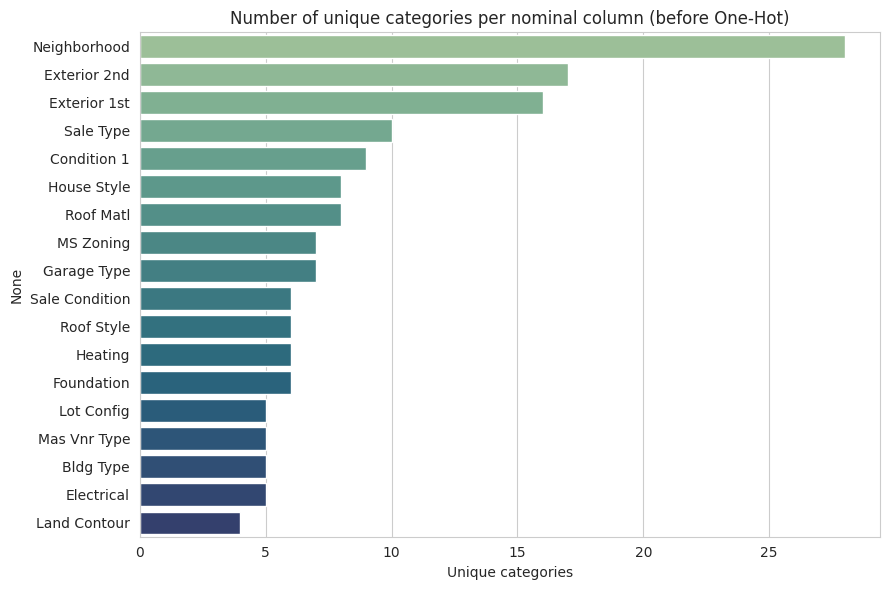

In [87]:
# كام قيمة فريدة في كل عمود nominal قبل الـ One-Hot؟ (ده بيفسر ليه عدد الأعمدة هيزيد كتير)
remaining_cat_cols_preview = df.select_dtypes(exclude=["number"]).columns.tolist()
ordinal_like = ["Exter Qual","Exter Cond","Bsmt Qual","Bsmt Cond","Heating QC","Kitchen Qual",
                "Fireplace Qu","Garage Qual","Garage Cond","Bsmt Exposure","BsmtFin Type 1",
                "BsmtFin Type 2","Garage Finish","Lot Shape","Land Slope","Functional",
                "Paved Drive","Street","Central Air"]
nominal_preview = [c for c in remaining_cat_cols_preview if c not in ordinal_like]

cardinality = df[nominal_preview].nunique().sort_values(ascending=False)
plt.figure(figsize=(9, 6))
sns.barplot(x=cardinality.values, y=cardinality.index, hue=cardinality.index, palette="crest", legend=False)
plt.title("Number of unique categories per nominal column (before One-Hot)")
plt.xlabel("Unique categories")
plt.tight_layout()
plt.savefig("fig_nominal_cardinality.png", dpi=150)
plt.show()

In [88]:
quality_map = {"NA": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
quality_cols = [c for c in [
    "Exter Qual", "Exter Cond", "Bsmt Qual", "Bsmt Cond",
    "Heating QC", "Kitchen Qual", "Fireplace Qu", "Garage Qual", "Garage Cond",
] if c in df.columns]
for col in quality_cols:
    df[col] = df[col].map(quality_map)

print("Quality columns encoded:", quality_cols)

Quality columns encoded: ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Heating QC', 'Kitchen Qual', 'Fireplace Qu', 'Garage Qual', 'Garage Cond']


In [89]:
ordinal_maps = {
    "Bsmt Exposure": {"NA": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFin Type 1": {"NA": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFin Type 2": {"NA": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "Garage Finish": {"NA": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "Lot Shape": {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3},
    "Land Slope": {"Sev": 0, "Mod": 1, "Gtl": 2},
    "Functional": {"Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3, "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7},
    "Paved Drive": {"N": 0, "P": 1, "Y": 2},
}
for col, mapping in ordinal_maps.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

print("Ordinal columns encoded:", list(ordinal_maps.keys()))

Ordinal columns encoded: ['Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Garage Finish', 'Lot Shape', 'Land Slope', 'Functional', 'Paved Drive']


In [90]:
binary_maps = {"Street": {"Grvl": 0, "Pave": 1}, "Central Air": {"N": 0, "Y": 1}}
for col, mapping in binary_maps.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

In [91]:
remaining_cat_cols = df.select_dtypes(exclude=["number"]).columns.tolist()
print(f"Nominal columns one-hot encoded ({len(remaining_cat_cols)}):", remaining_cat_cols)

df = pd.get_dummies(df, columns=remaining_cat_cols, drop_first=True)
print("Shape after encoding:", df.shape)

Nominal columns one-hot encoded (18): ['MS Zoning', 'Land Contour', 'Lot Config', 'Neighborhood', 'Condition 1', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Foundation', 'Heating', 'Electrical', 'Garage Type', 'Sale Type', 'Sale Condition']
Shape after encoding: (2930, 190)


9. Normalization

In [92]:
cols_to_exclude_from_scaling = [
    "SalePrice",                                                              # target: real units for reporting
    "Overall Qual", "Overall Cond",                                           # small-range ordinal ratings
    "Mo Sold", "Yr Sold",                                                     # calendar fields
    "Has_Alley", "Has_Fence", "Has_Pool QC", "Has_Misc Feature", "Has_Garage",  # binary flags
]
current_numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
cols_to_scale = [c for c in current_numeric_cols if c not in cols_to_exclude_from_scaling]

scaler = RobustScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"Columns scaled: {len(cols_to_scale)}")
print("Final clean (real-units) df shape :", df.shape)
print("Final scaled df shape             :", df_scaled.shape)

Columns scaled: 40
Final clean (real-units) df shape : (2930, 190)
Final scaled df shape             : (2930, 190)


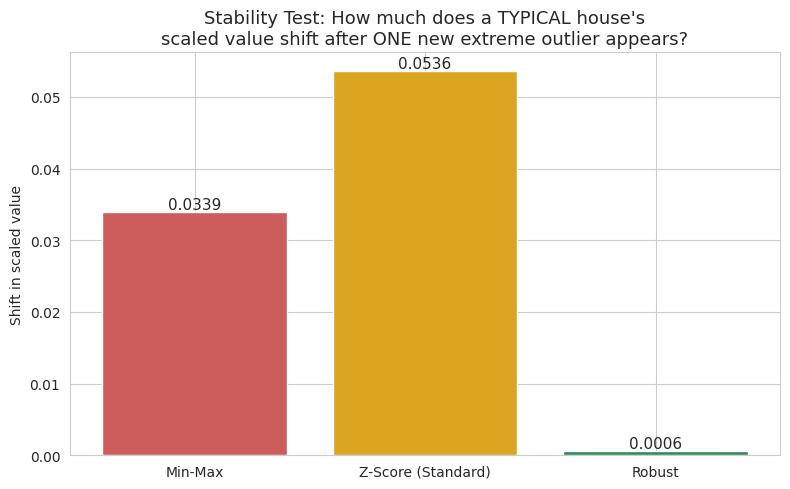

Min-Max              -> shift = 0.0339
Z-Score (Standard)   -> shift = 0.0536
Robust               -> shift = 0.0006


In [93]:
median_val = df["Lot Area"].median()
typical_idx = (df["Lot Area"] - median_val).abs().idxmin()
lot_area_raw = df[["Lot Area"]].reset_index(drop=True)

scalers_test = {"Min-Max": MinMaxScaler(), "Z-Score (Standard)": StandardScaler(), "Robust": RobustScaler()}

before_vals = {name: s.fit_transform(lot_area_raw).flatten()[typical_idx] for name, s in scalers_test.items()}

lot_area_with_outlier = pd.concat([lot_area_raw, pd.DataFrame({"Lot Area": [2_000_000]})], ignore_index=True)
after_vals = {name: s.fit_transform(lot_area_with_outlier).flatten()[typical_idx] for name, s in scalers_test.items()}

shifts = {name: abs(after_vals[name] - before_vals[name]) for name in scalers_test}

plt.figure(figsize=(8, 5))
bars = plt.bar(shifts.keys(), shifts.values(), color=["indianred", "goldenrod", "seagreen"])
plt.title("Stability Test: How much does a TYPICAL house's\nscaled value shift after ONE new extreme outlier appears?", fontsize=13)
plt.ylabel("Shift in scaled value")
for bar, v in zip(bars, shifts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.savefig("fig_scaler_stability.png", dpi=150)
plt.show()

for name, shift in shifts.items():
    print(f"{name:20s} -> shift = {shift:.4f}")

10. Outlier Handling

In [94]:
print("ملخص الـ Outliers حسب قاعدة IQR (للمعرفة فقط — لم يتم الحذف):\n")
for col in ["SalePrice", "Lot Area", "Gr Liv Area"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:15s} | {n_outliers:4d} outlier(s) ({n_outliers/len(df)*100:4.1f}%) | bounds=({lower:,.0f}, {upper:,.0f}) | max={df[col].max():,.0f}")

ملخص الـ Outliers حسب قاعدة IQR (للمعرفة فقط — لم يتم الحذف):

SalePrice       |  137 outlier(s) ( 4.7%) | bounds=(3,500, 339,500) | max=755,000
Lot Area        |  127 outlier(s) ( 4.3%) | bounds=(1,268, 17,728) | max=215,245
Gr Liv Area     |   75 outlier(s) ( 2.6%) | bounds=(201, 2,668) | max=5,642


11. Visualization

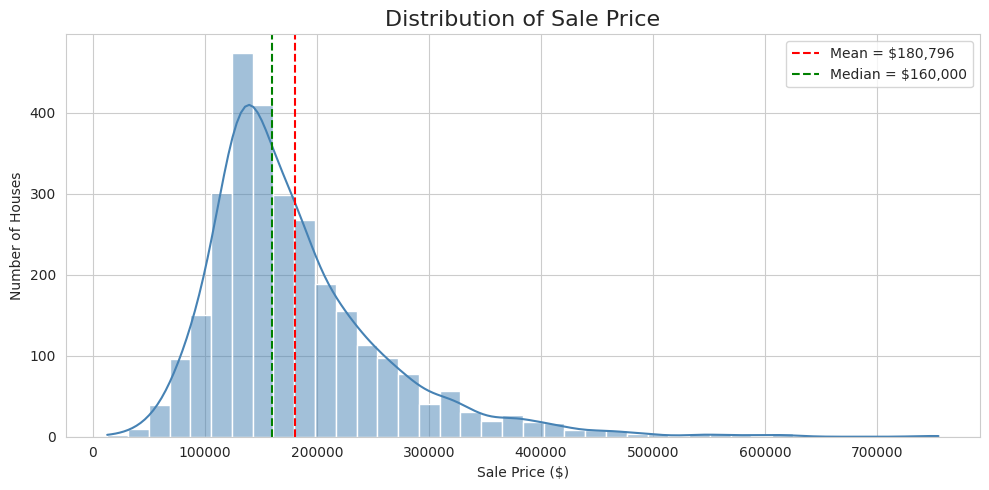

In [95]:
plt.figure(figsize=(10, 5))
sns.histplot(df["SalePrice"], kde=True, bins=40, color="steelblue")
plt.title("Distribution of Sale Price", fontdict={"size": 16})
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Houses")
plt.axvline(df["SalePrice"].mean(), color="red", linestyle="--",
            label=f"Mean = ${df['SalePrice'].mean():,.0f}")
plt.axvline(df["SalePrice"].median(), color="green", linestyle="--",
            label=f"Median = ${df['SalePrice'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.savefig("fig_01_saleprice_distribution.png", dpi=150)
plt.show()

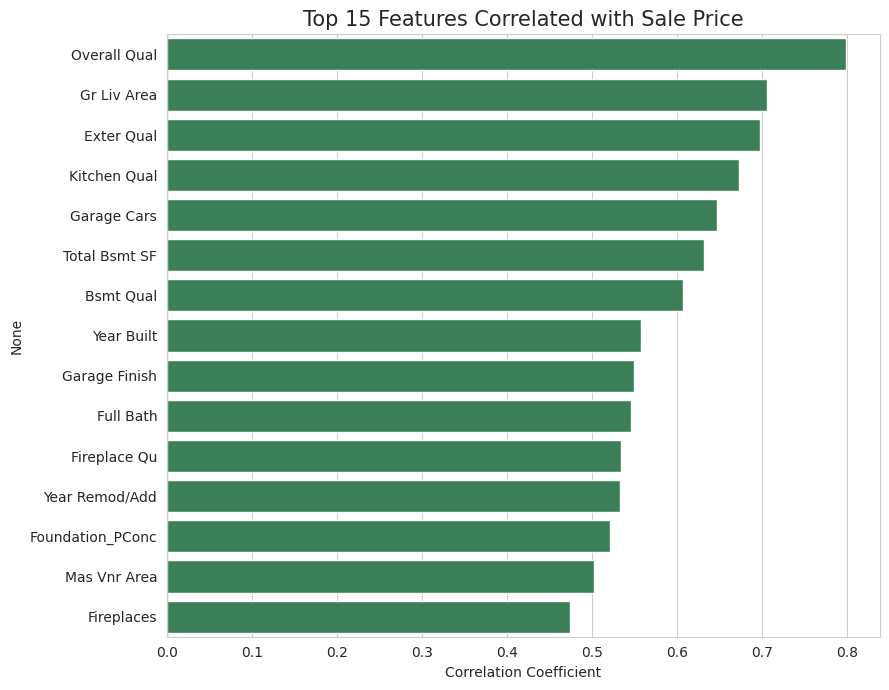

In [96]:
corr_with_price = (
    df.corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=abs, ascending=False)
)
top_15 = corr_with_price.head(15)

plt.figure(figsize=(9, 7))
bar_colors = ["seagreen" if v > 0 else "indianred" for v in top_15.values]
sns.barplot(x=top_15.values, y=top_15.index, hue=top_15.index,
            palette=bar_colors, legend=False)
plt.title("Top 15 Features Correlated with Sale Price", fontdict={"size": 15})
plt.xlabel("Correlation Coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("fig_02_top_correlations.png", dpi=150)
plt.show()

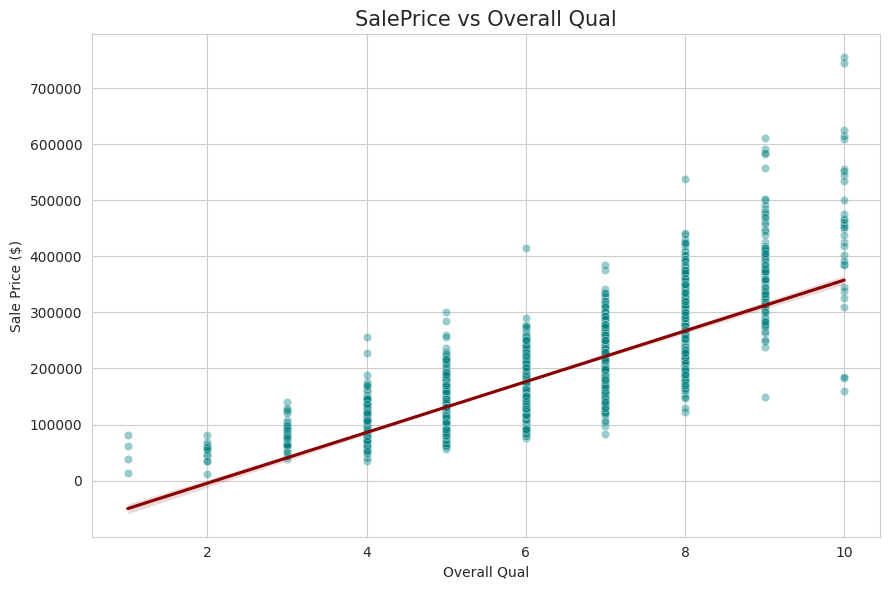

In [97]:
strongest_feature = corr_with_price.index[0]
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x=strongest_feature, y="SalePrice", alpha=0.4, color="teal")
sns.regplot(data=df, x=strongest_feature, y="SalePrice", scatter=False, color="darkred")
plt.title(f"SalePrice vs {strongest_feature}", fontdict={"size": 15})
plt.xlabel(strongest_feature)
plt.ylabel("Sale Price ($)")
plt.tight_layout()
plt.savefig("fig_03_strongest_relationship.png", dpi=150)
plt.show()

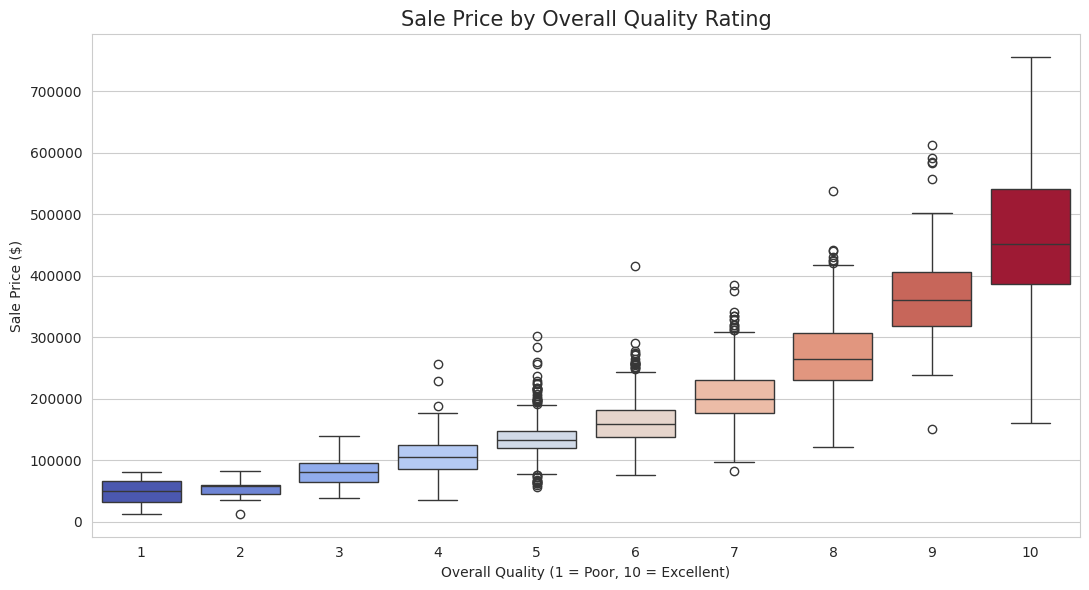

In [98]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x="Overall Qual", y="SalePrice", hue="Overall Qual",
            palette="coolwarm", legend=False)
plt.title("Sale Price by Overall Quality Rating", fontdict={"size": 15})
plt.xlabel("Overall Quality (1 = Poor, 10 = Excellent)")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
plt.savefig("fig_04_price_by_quality.png", dpi=150)
plt.show()

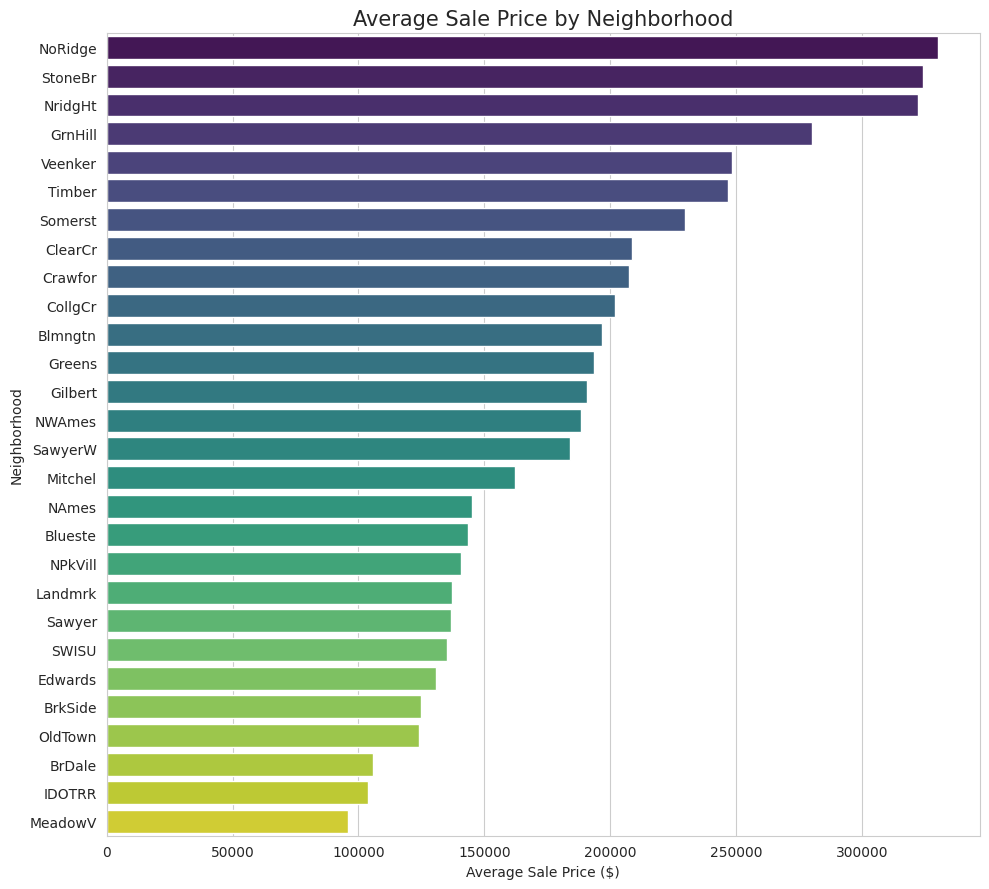

In [99]:
neighborhood_avg = (
    df_clean_pre_encoding.groupby("Neighborhood")["SalePrice"]
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10, 9))
sns.barplot(x=neighborhood_avg.values, y=neighborhood_avg.index,
            hue=neighborhood_avg.index, palette="viridis", legend=False)
plt.title("Average Sale Price by Neighborhood", fontdict={"size": 15})
plt.xlabel("Average Sale Price ($)")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.savefig("fig_05_price_by_neighborhood.png", dpi=150)
plt.show()

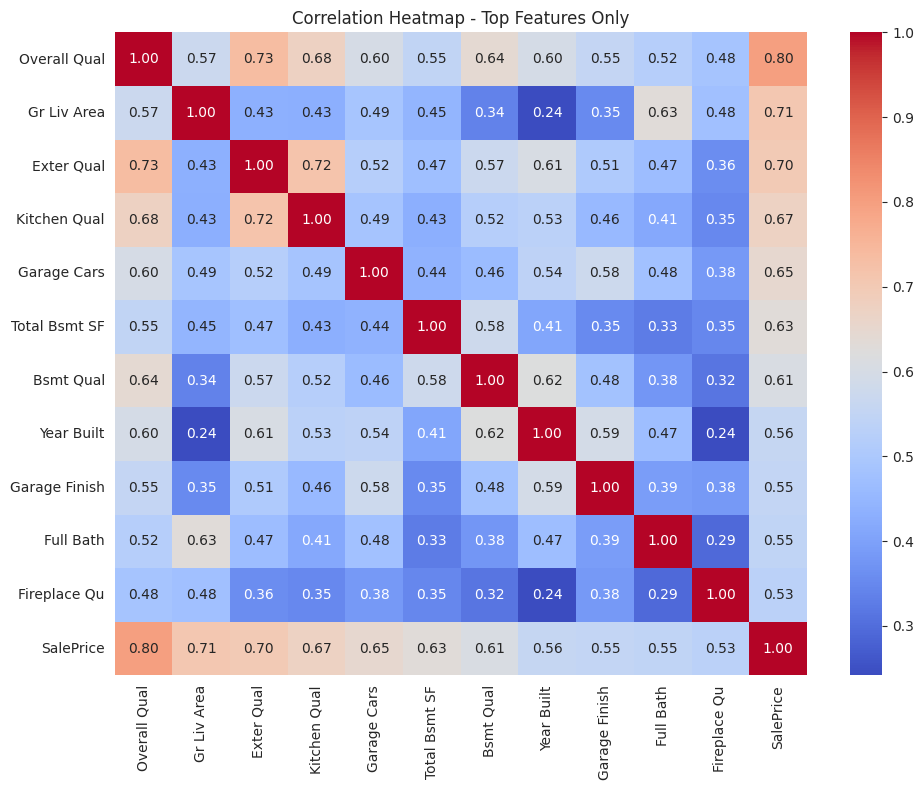

In [100]:
top_features = corr_with_price.head(11).index.tolist() + ["SalePrice"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Top Features Only")
plt.tight_layout()
plt.savefig("fig_06_top_features_heatmap.png", dpi=150)
plt.show()

12. Export

In [105]:
df_clean_pre_encoding.to_csv("ames_clean_readable.csv", index=False)
df.to_csv("ames_clean_encoded.csv", index=False)
df_scaled.to_csv("ames_clean_encoded_scaled.csv", index=False)


print(" - ames_clean_readable.csv                   ", df_clean_pre_encoding.shape)
print(" - ames_clean_encoded.csv                    ", df.shape)
print(" - ames_clean_encoded_scaled.csv             ", df_scaled.shape)

 - ames_clean_readable.csv                    (2930, 68)
 - ames_clean_encoded.csv                     (2930, 190)
 - ames_clean_encoded_scaled.csv              (2930, 190)


13. Key Findings & Business Recommendations

In [102]:
top_neighborhoods = neighborhood_avg.head(3)
bottom_neighborhoods = neighborhood_avg.tail(3)
skew_direction = "right-skewed (a few high-priced homes pull the average up)" \
    if df["SalePrice"].mean() > df["SalePrice"].median() else "left-skewed"

print("=" * 70)
print("KEY FINDINGS")
print("=" * 70)
print(f"""
1. Price distribution:
   SalePrice is {skew_direction}.
   Mean = ${df['SalePrice'].mean():,.0f} | Median = ${df['SalePrice'].median():,.0f}

2. Strongest price drivers (by correlation with SalePrice):
{top_15.head(5).to_string()}

3. Overall Quality has a strong, monotonic relationship with price
   (correlation = {corr_with_price['Overall Qual']:.2f}) -> each additional
   quality point is associated with a clear, consistent price premium.

4. Highest-priced neighborhoods:
{top_neighborhoods.to_string()}

5. Lowest-priced neighborhoods:
{bottom_neighborhoods.to_string()}
""")

KEY FINDINGS

1. Price distribution:
   SalePrice is right-skewed (a few high-priced homes pull the average up).
   Mean = $180,796 | Median = $160,000

2. Strongest price drivers (by correlation with SalePrice):
Overall Qual    0.799262
Gr Liv Area     0.706780
Exter Qual      0.697970
Kitchen Qual    0.672914
Garage Cars     0.647562

3. Overall Quality has a strong, monotonic relationship with price
   (correlation = 0.80) -> each additional
   quality point is associated with a clear, consistent price premium.

4. Highest-priced neighborhoods:
Neighborhood
NoRidge    330319.126761
StoneBr    324229.196078
NridgHt    322018.265060

5. Lowest-priced neighborhoods:
Neighborhood
BrDale     105608.333333
IDOTRR     103752.903226
MeadowV     95756.486486



In [103]:
print("=" * 70)
print("BUSINESS RECOMMENDATIONS")
print("=" * 70)
print(f"""
- Renovation ROI: Since Overall Quality, Kitchen Qual and Exter Qual are
  all in the top correlated features, quality-focused renovations
  (kitchen, exterior finish) are likely to yield the strongest price lift
  relative to size-only additions.
- Investment targeting: {top_neighborhoods.index[0]}, {top_neighborhoods.index[1]}
  and {top_neighborhoods.index[2]} command the highest average prices and
  may offer the best resale positioning for premium listings.
- Value opportunities: {bottom_neighborhoods.index[0]} and
  {bottom_neighborhoods.index[1]} show the lowest average prices and could
  be worth investigating for undervalued-entry investment opportunities.
- Next step: given the skew in SalePrice, a log-transform of the target
  should be tested before any regression modeling, to stabilize variance.
""")

BUSINESS RECOMMENDATIONS

- Renovation ROI: Since Overall Quality, Kitchen Qual and Exter Qual are
  all in the top correlated features, quality-focused renovations
  (kitchen, exterior finish) are likely to yield the strongest price lift
  relative to size-only additions.
- Investment targeting: NoRidge, StoneBr
  and NridgHt command the highest average prices and
  may offer the best resale positioning for premium listings.
- Value opportunities: BrDale and
  IDOTRR show the lowest average prices and could
  be worth investigating for undervalued-entry investment opportunities.
- Next step: given the skew in SalePrice, a log-transform of the target
  should be tested before any regression modeling, to stabilize variance.

